Epoch [0/2000], Loss: 1.131149
Epoch [200/2000], Loss: 0.625128
Epoch [400/2000], Loss: 0.509318
Epoch [600/2000], Loss: 0.463251
Epoch [800/2000], Loss: 0.451696
Epoch [1000/2000], Loss: 0.450834
Epoch [1200/2000], Loss: 0.450752
Epoch [1400/2000], Loss: 0.450742
Epoch [1600/2000], Loss: 0.450727
Epoch [1800/2000], Loss: 0.450743
Test Loss: 0.439389


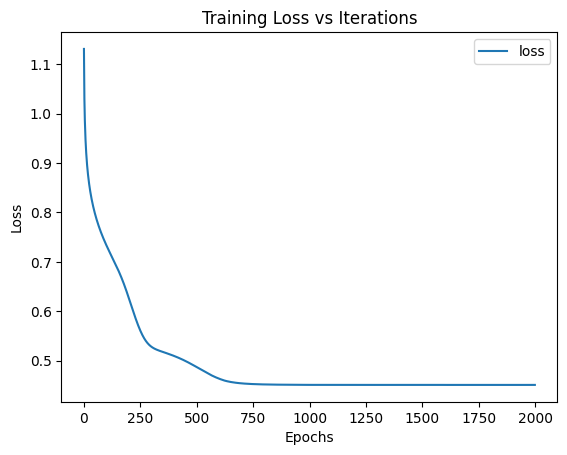

Name: MAHALINGA JEYANTH V
Register Number: 212224220057
Input Age: 30
Predicted Spending Score (numeric): 0.27
Predicted Spending Score (label): Low


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load Dataset
dataset1 = pd.read_csv('/content/customers (2).csv')

# Numeric input: Age
X = dataset1[['Age']].values

# Numeric output: Spending_Score mapped to numbers
spending_score_mapping = {'Low': 0, 'Average': 1, 'High': 2}
y = dataset1['Spending_Score'].map(spending_score_mapping).values.reshape(-1, 1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=33
)

# Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Name: MAHALINGA JEYANTH V
# Register Number: 212224220057
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Name: MAHALINGA JEYANTH V
# Register Number: 212224220057
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(ai_brain.parameters(), lr=0.001)

def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(ai_brain(X_train), y_train)
        loss.backward()
        optimizer.step()
        ai_brain.history['loss'].append(loss.item())

        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')

# Name: MAHALINGA JEYANTH V
# Register Number: 212224220057
loss_df = pd.DataFrame(ai_brain.history)
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Iterations")
plt.show()

# New Sample Prediction
print('Name: MAHALINGA JEYANTH V')
print('Register Number: 212224220057')

X_new = torch.tensor([[30]], dtype=torch.float32)
X_new_scaled = torch.tensor(scaler.transform(X_new), dtype=torch.float32)

with torch.no_grad():
    prediction = ai_brain(X_new_scaled).item()

# Map back to label
if prediction < 0.5:
    label = 'Low'
elif prediction < 1.5:
    label = 'Average'
else:
    label = 'High'

print(f'Input Age: 30')
print(f'Predicted Spending Score (numeric): {prediction:.2f}')
print(f'Predicted Spending Score (label): {label}')